
<br>
<font face="Times New Roman">
<div dir=ltr align=center>
<font color=0F5298 size=7>
Digital Image Processing <br>
<font color=2565AE size=5>
Department Of Mathematical Sciences <br>
Spring 2025<br>
<font color=3C99D size=5>
Assignment 4 <br>
</div>


---



### Full Name : Amir Malekhosseini
### Student Number : 401100528
___

# Imports and Helper Functions

In [ ]:
# Import necessary libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
import os

# Helper function for plotting single images
def show_image(image, title='Image', cmap=None, figsize=(6,6)):
    plt.figure(figsize=figsize)
    if len(image.shape) == 3 and image.shape[2] == 3: # Color image
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    elif cmap: 
        plt.imshow(image, cmap=cmap)
    else: 
        plt.imshow(image, cmap='gray') 
    plt.title(title)
    plt.axis('off')
    plt.show()

# Helper function for plotting multiple images
def show_images(images, titles, cmap_list=None, figsize_per_image=(5,5)):
    n = len(images)
    if cmap_list is None:
        cmap_list = [None] * n
    elif isinstance(cmap_list, str):
        cmap_list = [cmap_list] * n
        
    total_width = figsize_per_image[0] * n
    total_height = figsize_per_image[1]
    
    plt.figure(figsize=(total_width, total_height))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img_to_show = images[i]
        if len(img_to_show.shape) == 3 and img_to_show.shape[2] == 3: # Color image
             plt.imshow(cv2.cvtColor(img_to_show, cv2.COLOR_BGR2RGB))
        elif cmap_list[i]:
            plt.imshow(img_to_show, cmap=cmap_list[i])
        else: 
            plt.imshow(img_to_show, cmap='gray') 
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Create dummy image files if they don't exist for testing
def create_dummy_images():
    
    if not os.path.exists("noisy_image.png"):
        print("Creating dummy noisy_image.png")
        dummy_clean = np.zeros((100, 100), dtype=np.uint8)
        cv2.rectangle(dummy_clean, (25,25), (75,75), 255, -1)
        # Add salt noise
        salt_noise = np.random.rand(100,100) < 0.1
        dummy_noisy = np.copy(dummy_clean)
        dummy_noisy[salt_noise] = 255
        # Add pepper noise
        pepper_noise = np.random.rand(100,100) < 0.1
        dummy_noisy[pepper_noise & (dummy_clean == 255)] = 0 
        dummy_noisy[pepper_noise & (dummy_clean == 0)] = 0 
        cv2.imwrite("noisy_image.png", dummy_noisy)

    if not os.path.exists("Q2.png"):
        print("Creating dummy Q2.png")
        q2_dummy = np.zeros((200, 200), dtype=np.uint8)
        cv2.line(q2_dummy, (50, 30), (50, 170), 255, 5) # Thick vertical
        cv2.line(q2_dummy, (70, 50), (70, 150), 255, 2) # Thin vertical
        cv2.line(q2_dummy, (30, 100), (170, 100), 255, 4) # Horizontal
        cv2.circle(q2_dummy, (150,50), 10, 255, -1)     # Circle
        for i in range(5):
            cv2.circle(q2_dummy, (120 + i*10, 150 + i*5), 2, 255, -1) # Dots
        cv2.imwrite("Q2.png", q2_dummy)

    if not os.path.exists("leaf.jpg"):
        print("Creating dummy leaf.jpg")
        leaf_dummy = np.full((200, 200), 50, dtype=np.uint8) 
        cv2.ellipse(leaf_dummy, (100,100), (70,40), 30, 0, 360, 200, -1) 
        cv2.imwrite("leaf.jpg", leaf_dummy)

    if not os.path.exists("Coins.png"):
        print("Creating dummy Coins.png")
        coins_dummy = np.full((300, 400, 3), (180,180,180), dtype=np.uint8) 
        cv2.circle(coins_dummy, (80, 80), 35, (100,100,100), -1)
        cv2.circle(coins_dummy, (200, 100), 40, (120,120,120), -1)
        small_coin_centers = [(50,200), (100,220), (150,180), (200,230), (250,200), (300,250), (330,180)]
        small_coin_radii = [15, 12, 14, 16, 13, 10, 11]
        for i in range(7):
            cv2.circle(coins_dummy, small_coin_centers[i], small_coin_radii[i], (150,150,150), -1)
        cv2.imwrite("Coins.png", coins_dummy)

    leaf_image_folder = "Leaves"
    os.makedirs(leaf_image_folder, exist_ok=True)
    autumn_leaf_fnames = [f"autumn_leaf_{i}.png" for i in range(1, 4)]
    banana_leaf_fnames = [f"banana_leaf_{i}.png" for i in range(1, 4)]
    
    for fname in autumn_leaf_fnames + banana_leaf_fnames:
        path = os.path.join(leaf_image_folder, fname)
        if not os.path.exists(path):
            print(f"Creating dummy {fname}")
            dummy_leaf_q3 = np.full((200, 200, 3), (30,30,30) if "autumn" in fname else (40,40,40) , dtype=np.uint8)
            if "autumn" in fname: 
                cv2.ellipse(dummy_leaf_q3, (100,100), (np.random.randint(60,75), np.random.randint(45,60)), 
                            np.random.randint(0,45), 0, 360, (70,70,180+np.random.randint(0,55)), -1)
            else: 
                cv2.ellipse(dummy_leaf_q3, (100,100), (np.random.randint(80,95), np.random.randint(25,35)), 
                            np.random.randint(0,20), 0, 360, (70,180+np.random.randint(0,55),70), -1)
            cv2.imwrite(path, dummy_leaf_q3)

create_dummy_images() # Call this once to ensure files exist

# Dilation and Erosion

In [ ]:
def dilate(image, structuring_element):
    if len(image.shape) > 2:
        raise ValueError("Input image must be 2D (grayscale or binary)")
    img_h, img_w = image.shape
    se_h, se_w = structuring_element.shape
    
    # Determine padding size (origin of SE is its center)
    pad_h_before = se_h // 2
    pad_w_before = se_w // 2
    pad_h_after = se_h - pad_h_before - 1
    pad_w_after = se_w - pad_w_before - 1
    
    dilated_image = np.zeros_like(image)
    
    padded_image = np.pad(image, ((pad_h_before, pad_h_after), (pad_w_before, pad_w_after)), mode='constant', constant_values=0)
    
    for r_out in range(img_h):
        for c_out in range(img_w):
            max_val = 0 
            
            # Iterate over the structuring element
            for r_se in range(se_h):
                for c_se in range(se_w):
                    if structuring_element[r_se, c_se] == 1: 
                       
                        img_val = padded_image[r_out + r_se, c_out + c_se]
                        if img_val > max_val:
                            max_val = img_val
            dilated_image[r_out, c_out] = max_val
            
    return dilated_image

In [ ]:
def erode(image, structuring_element):
    if len(image.shape) > 2:
        raise ValueError("Input image must be 2D (grayscale or binary)")
    img_h, img_w = image.shape
    se_h, se_w = structuring_element.shape
    
    pad_h_before = se_h // 2
    pad_w_before = se_w // 2
    pad_h_after = se_h - pad_h_before - 1
    pad_w_after = se_w - pad_w_before - 1
    
    eroded_image = np.zeros_like(image)
    
    max_pixel_val = 255 if image.dtype == np.uint8 else np.max(image) # More general
    padded_image = np.pad(image, ((pad_h_before, pad_h_after), (pad_w_before, pad_w_after)), mode='constant', constant_values=max_pixel_val)

    for r_out in range(img_h):
        for c_out in range(img_w):
            min_val = max_pixel_val 
            
            for r_se in range(se_h):
                for c_se in range(se_w):
                    if structuring_element[r_se, c_se] == 1: 
                        img_val = padded_image[r_out + r_se, c_out + c_se]
                        if img_val < min_val:
                            min_val = img_val
            eroded_image[r_out, c_out] = min_val
            
    return eroded_image

## Noise Reduction

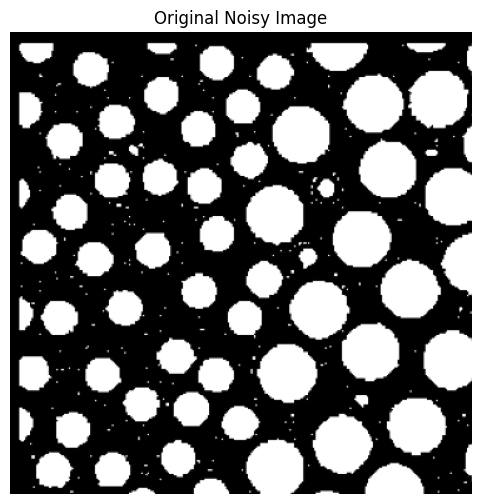

In [61]:
path_noisy = "noisy_image.png"
noisy_image = cv2.imread(path_noisy, 0)
if noisy_image is None:
    print(f"Error: Could not load image from {path_noisy}")
else:
    show_image(noisy_image, title="Original Noisy Image")

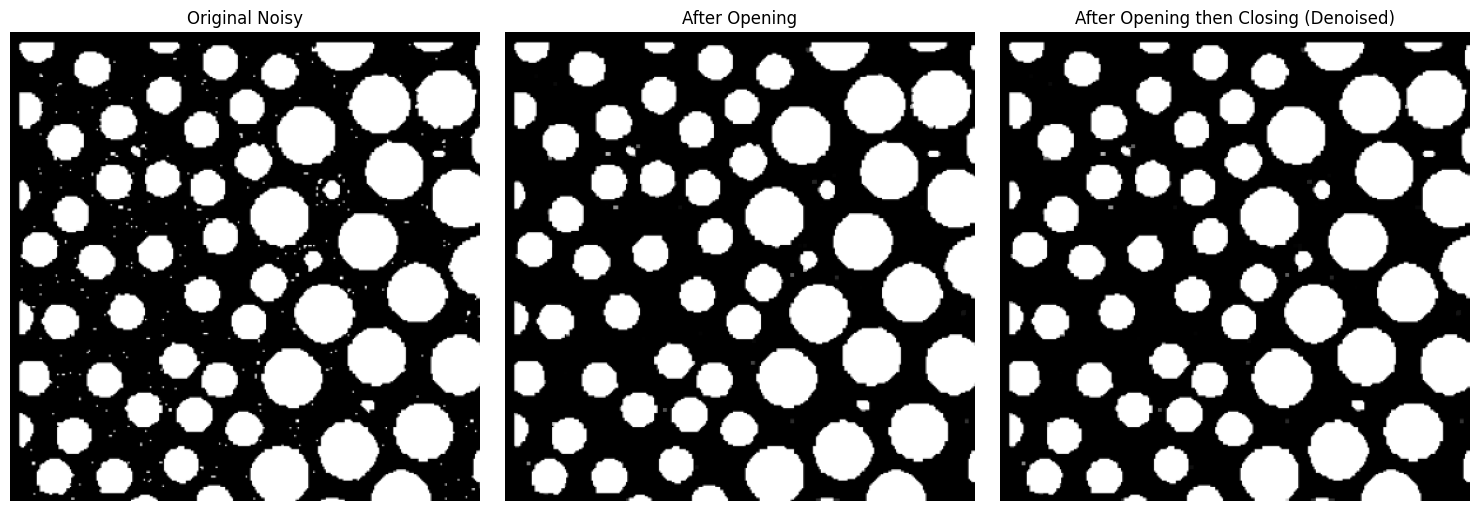

In [ ]:
if noisy_image is not None:
    
    se_noise_reduction = np.ones((3, 3), dtype=np.uint8)

    # To remove salt noise (small white spots), use Opening (erosion then dilation).
    # To remove pepper noise (small black spots), use Closing (dilation then erosion).

    # Step 1: Opening to remove salt-like noise
    eroded_for_opening = erode(noisy_image, se_noise_reduction)
    opened_image = dilate(eroded_for_opening, se_noise_reduction)

    # Step 2: Closing on the opened image to remove pepper-like noise
    dilated_for_closing = dilate(opened_image, se_noise_reduction)
    denoised_image = erode(dilated_for_closing, se_noise_reduction)

    # Show results
    show_images([noisy_image, opened_image, denoised_image], 
                ["Original Noisy", "After Opening", "After Opening then Closing (Denoised)"])

## Parallel Vertical Lines

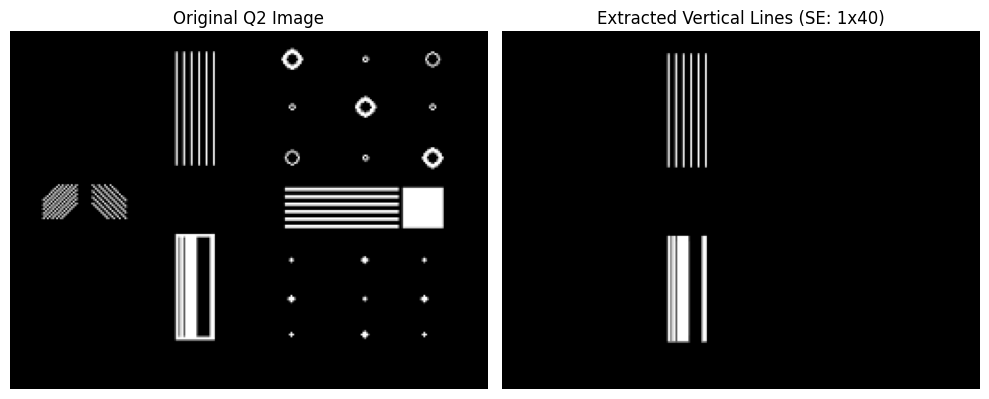

In [ ]:
path_q2 = "Q2.png"
q2_image = cv2.imread(path_q2, 0)

if q2_image is None:
    print(f"Error: Could not load image from {path_q2}.")
else:
    if 'shown_q2_original_for_lines' not in globals():
        shown_q2_original_for_lines = True  

    # For Vertical Lines:
    se_vertical_height = 40
    se_vertical_width = 1

    vertical_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT, (se_vertical_width, se_vertical_height))

    extracted_vertical_lines = cv2.morphologyEx(
        q2_image, cv2.MORPH_OPEN, vertical_kernel)

    show_images([q2_image, extracted_vertical_lines],
                ["Original Q2 Image", f"Extracted Vertical Lines (SE: {se_vertical_width}x{se_vertical_height})"])

## Parallel Horizontal Lines

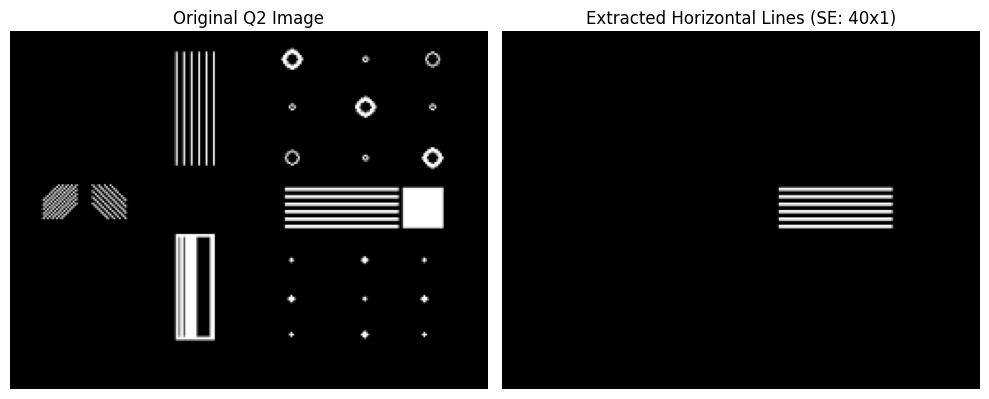

In [ ]:
if q2_image is not None:  
    # For Horizontal Lines:
    se_horizontal_width = 40
    se_horizontal_height = 1 

    horizontal_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT, (se_horizontal_width, se_horizontal_height))

    extracted_horizontal_lines = cv2.morphologyEx(
        q2_image, cv2.MORPH_OPEN, horizontal_kernel)

    show_images([q2_image, extracted_horizontal_lines],
                ["Original Q2 Image", f"Extracted Horizontal Lines (SE: {se_horizontal_width}x{se_horizontal_height})"])
else:
    print("Cannot extract horizontal lines because Q2_image was not loaded.")

## Edge Detecting

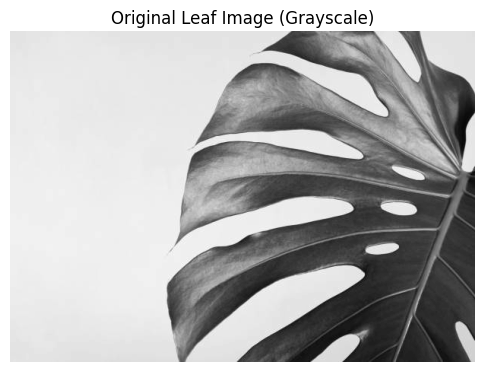

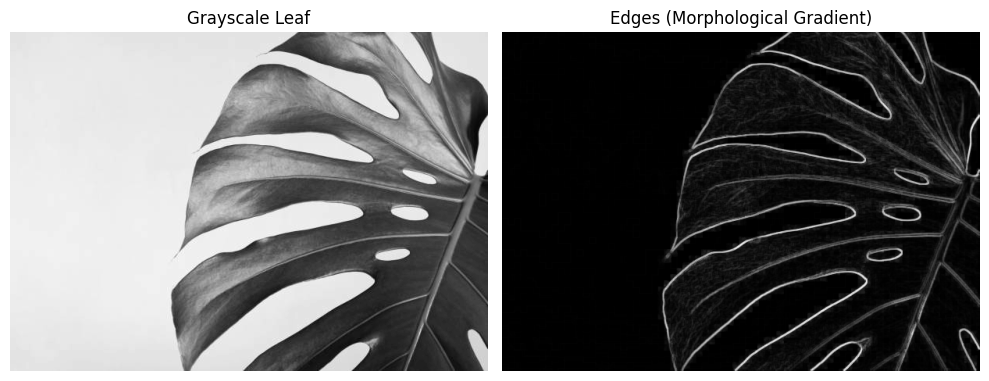

In [ ]:
path_leaf = "leaf.jpg"
leaf_image_color = cv2.imread(path_leaf) 
if leaf_image_color is None:
    print(f"Error: Could not load image from {path_leaf}")
else:
    leaf_image_gray = (
        cv2.cvtColor(leaf_image_color, cv2.COLOR_BGR2GRAY)
        if len(leaf_image_color.shape) == 3
        else leaf_image_color
    )
    show_image(leaf_image_gray, title="Original Leaf Image (Grayscale)")

    # --- Compute morphological gradient directly on the grayscale image ---
    se_edge = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

    dilated_leaf = cv2.dilate(leaf_image_gray, se_edge)
    eroded_leaf = cv2.erode(leaf_image_gray, se_edge)

    edges = cv2.subtract(dilated_leaf, eroded_leaf)

    show_images(
        [leaf_image_gray, edges],
        ["Grayscale Leaf", "Edges (Morphological Gradient)"],
        cmap_list="gray"
    )

# Counting Coins

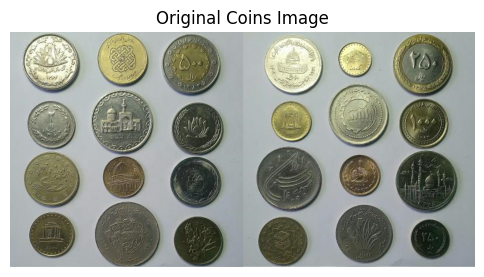

In [66]:
path_coins = "Coins.png"
coins_color = cv2.imread(path_coins)
if coins_color is None:
    print(f"Error: Could not load image from {path_coins}")
else:
    show_image(coins_color, title="Original Coins Image")

--- Step 1: PREPROCESSING ---


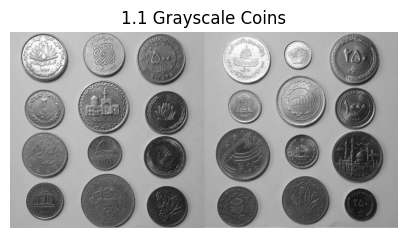

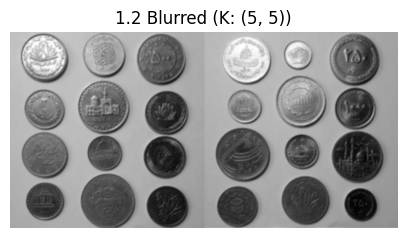

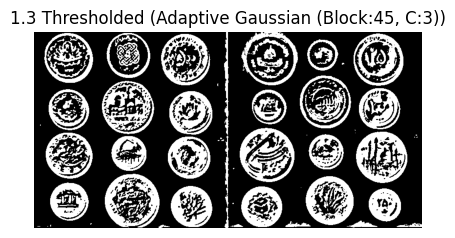

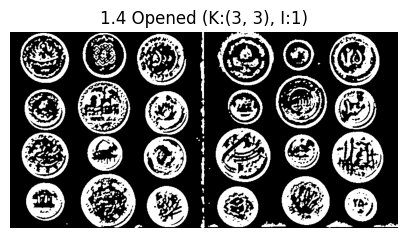

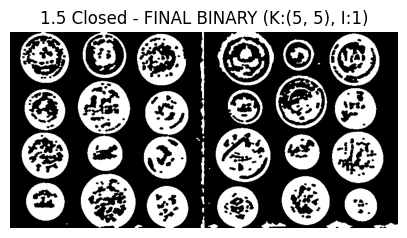


--- Step 2: CONNECTED COMPONENTS ---
Analyzing detected components (before size filtering)...


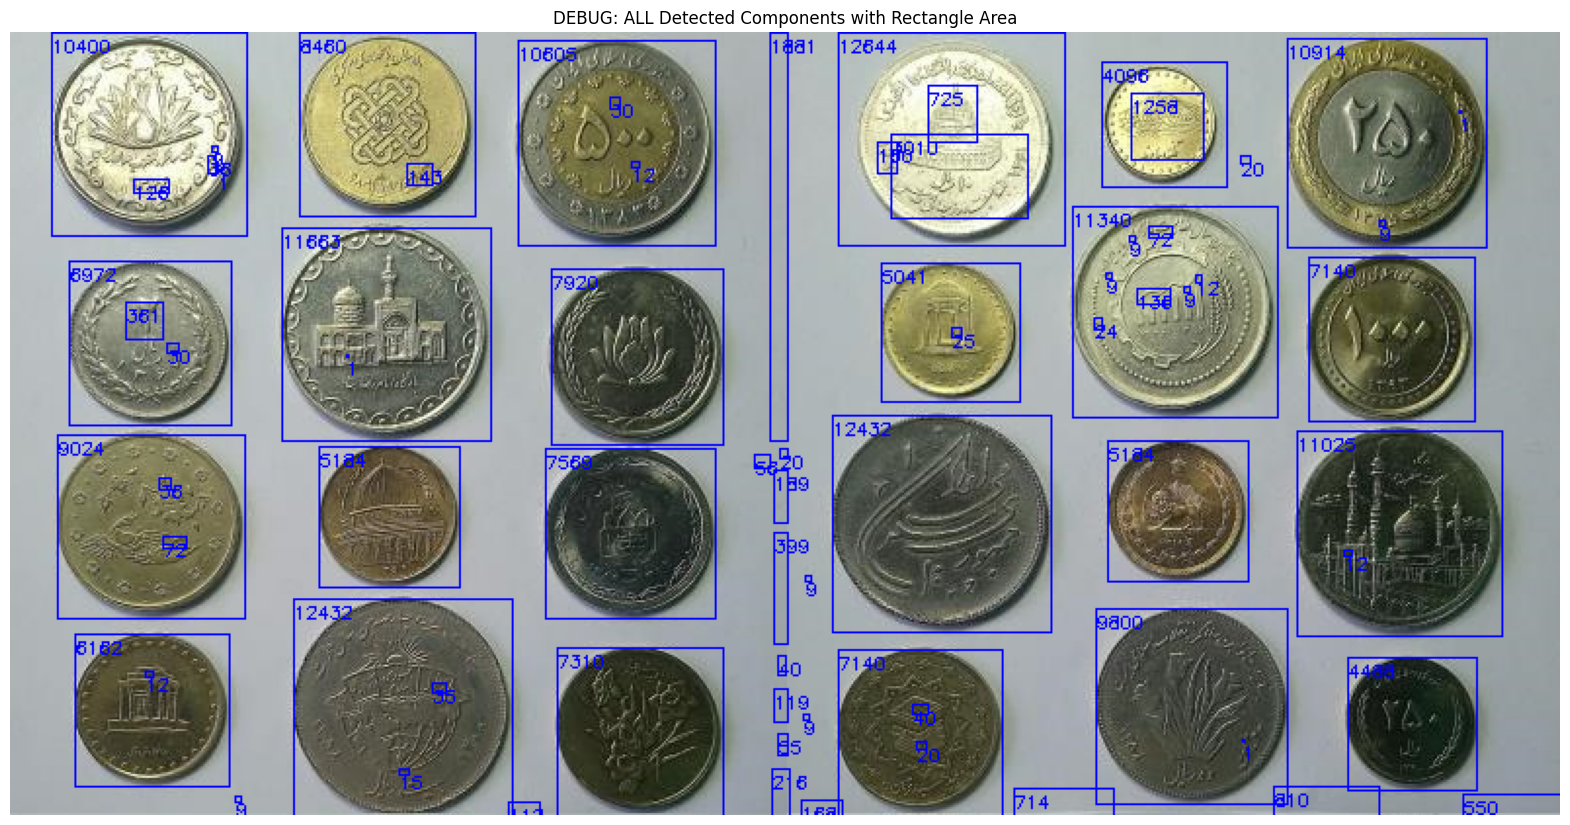

--- >>> Sorted areas of ALL detected components (excluding background): <<< ---
First 20: [ 1  1  1  1  9  9  9  9  9  9  9  9 12 12 12 12 15 20 20 20] 
Last 20: [ 5184  6162  6972  7140  7140  7310  7569  7920  8460  9024  9800 10400
 10605 10914 11025 11340 11663 12432 12432 12644]

--- Step 3: FILTER BY AREA and COUNT ---

Final count of small coins detected: 7
Final count of large coins detected: 17
SUCCESS: Correctly detected 7 small coins!


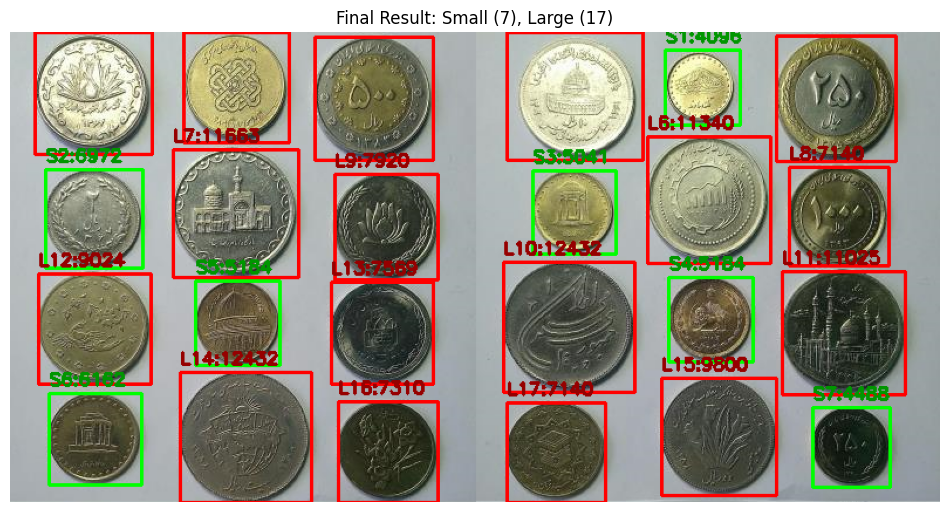

In [ ]:


if 'coins_color' in locals() and coins_color is not None and np.any(coins_color):  # Check if not dummy
    print("--- Step 1: PREPROCESSING ---")

    if len(coins_color.shape) == 3 and coins_color.shape[2] == 3:
        coins_gray = cv2.cvtColor(coins_color, cv2.COLOR_BGR2GRAY)
    elif len(coins_color.shape) == 2:
        print("Input image is already grayscale.")
        coins_gray = coins_color
    else:
        print("ERROR: Unsupported image format for coins_color. Exiting.")

    show_image(coins_gray, title="1.1 Grayscale Coins", figsize=(5, 5))

    blur_ksize = (5, 5)

    block_size = 45          
    C_const = 3              

    open_ksize_val = (3, 3)
    open_iter_val = 1      

    close_ksize_val = (5, 5)  
    close_iter_val = 1       

    coins_blurred = cv2.GaussianBlur(coins_gray, blur_ksize, 0)
    show_image(coins_blurred,
               title=f"1.2 Blurred (K: {blur_ksize})", figsize=(5, 5))

    coins_thresh = cv2.adaptiveThreshold(coins_blurred, 255,
                                         cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                         cv2.THRESH_BINARY_INV,
                                         block_size, C_const)
    threshold_type_str = f"Adaptive Gaussian (Block:{block_size}, C:{C_const})"
    show_image(
        coins_thresh, title=f"1.3 Thresholded ({threshold_type_str})", figsize=(5, 5))

    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, open_ksize_val)
    coins_opened = cv2.morphologyEx(
        coins_thresh, cv2.MORPH_OPEN, kernel_open, iterations=open_iter_val)
    show_image(
        coins_opened, title=f"1.4 Opened (K:{open_ksize_val}, I:{open_iter_val})", figsize=(5, 5))

    kernel_close = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, close_ksize_val)
    coins_processed = cv2.morphologyEx(
        coins_opened, cv2.MORPH_CLOSE, kernel_close, iterations=close_iter_val)
    show_image(coins_processed,
               title=f"1.5 Closed - FINAL BINARY (K:{close_ksize_val}, I:{close_iter_val})", figsize=(5, 5))

    print("\n--- Step 2: CONNECTED COMPONENTS ---")
    num_labels, labels_map, stats, centroids = cv2.connectedComponentsWithStats(
        coins_processed, connectivity=8)

    temp_visualization_all_components = coins_color.copy()
    print("Analyzing detected components (before size filtering)...")
    all_component_areas = []
    if num_labels > 1:
        for i in range(1, num_labels):
            # Calculate bounding-box area instead of pixel count
            x = stats[i, cv2.CC_STAT_LEFT]
            y = stats[i, cv2.CC_STAT_TOP]
            w = stats[i, cv2.CC_STAT_WIDTH]
            h = stats[i, cv2.CC_STAT_HEIGHT]
            rect_area = w * h
            all_component_areas.append(rect_area)

            cv2.rectangle(temp_visualization_all_components,
                          (x, y), (x + w, y + h), (255, 0, 0), 1)
            cv2.putText(temp_visualization_all_components, str(
                rect_area), (x, y + 10), cv2.FONT_HERSHEY_SIMPLEX, 0.30, (250, 0, 0), 1)

        show_image(temp_visualization_all_components,
                   title="DEBUG: ALL Detected Components with Rectangle Area", figsize=(20, 15))
        sorted_areas = np.sort(np.array(all_component_areas))
        print("--- >>> Sorted areas of ALL detected components (excluding background): <<< ---")
        if len(sorted_areas) < 40:
            print(sorted_areas)
        else:
            print("First 20:", sorted_areas[:20],
                  "\nLast 20:", sorted_areas[-20:])
    else:
        print("No components detected after processing. Check preprocessing parameters.")

    print("\n--- Step 3: FILTER BY AREA and COUNT ---")
    min_area_for_any_coin = 2500
    area_threshold_for_small_coins = 7000

    aspect_ratio_min = 0.80
    aspect_ratio_max = 1.10

  

    small_coins_count = 0
    large_coins_count = 0
    output_image_with_boxes_final = coins_color.copy()

    if num_labels > 1:
        for i in range(1, num_labels):
            # Calculate bounding-box area instead of pixel count
            x = stats[i, cv2.CC_STAT_LEFT]
            y = stats[i, cv2.CC_STAT_TOP]
            w = stats[i, cv2.CC_STAT_WIDTH]
            h = stats[i, cv2.CC_STAT_HEIGHT]
            if w == 0 or h == 0:
                continue

            rect_area = w * h
            aspect_ratio = w / float(h)
            is_coin_like_shape = (
                aspect_ratio > aspect_ratio_min and aspect_ratio < aspect_ratio_max)

            if is_coin_like_shape and rect_area >= min_area_for_any_coin:
                if rect_area < area_threshold_for_small_coins:
                    small_coins_count += 1
                    cv2.rectangle(output_image_with_boxes_final, (x, y),
                                  (x + w, y + h), (0, 255, 0), 2)
                    cv2.putText(output_image_with_boxes_final, f"S{small_coins_count}:{rect_area}", (x, y - 7),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 150, 0), 2)
                else:
                    large_coins_count += 1
                    cv2.rectangle(output_image_with_boxes_final, (x, y),
                                  (x + w, y + h), (0, 0, 255), 2)
                    cv2.putText(output_image_with_boxes_final, f"L{large_coins_count}:{rect_area}", (x, y - 7),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 150), 2)

    print(f"\nFinal count of small coins detected: {small_coins_count}")
    print(f"Final count of large coins detected: {large_coins_count}")

    target_small_coins = 7
    if small_coins_count == target_small_coins:
        print(f"SUCCESS: Correctly detected {target_small_coins} small coins!")
    else:
        print(
            f"INFO: Detected {small_coins_count} small coins. Target was {target_small_coins}.")
        print(">>> ADJUST 'min_area_for_any_coin' AND 'area_threshold_for_small_coins' <<<")
        print(">>> based on the 'Sorted areas' printout and visual inspection of '1.5 Closed' and 'DEBUG' images. <<<")
        print(">>> Also check adaptive threshold params ('block_size', 'C_const'), morph ops, and aspect ratio filter. <<<")

    show_image(output_image_with_boxes_final,
               title=f"Final Result: Small ({small_coins_count}), Large ({large_coins_count})", figsize=(12, 12))

else:
    print("Original coins_color image not loaded or available. Cannot perform coin counting.")

# Shape Descriptors

In [ ]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


Load the Images

Loaded 6 leaf images for Q3.


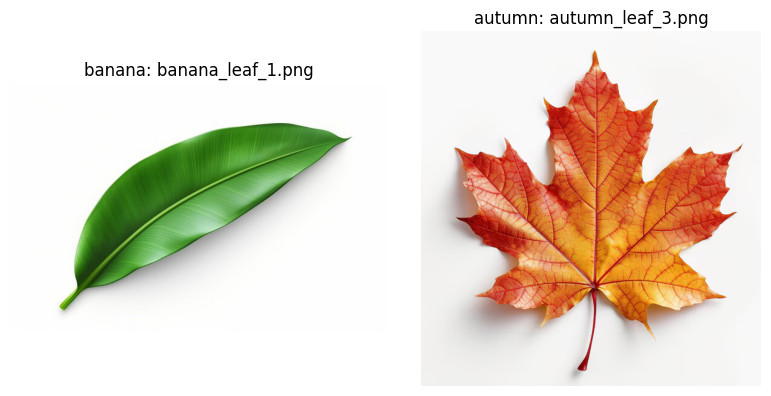

In [ ]:
leaf_image_folder = "Leaves/"
autumn_leaf_fnames = [f"autumn_leaf_{i}.png" for i in range(1, 4)]
banana_leaf_fnames = [f"banana_leaf_{i}.png" for i in range(1, 4)]

leaf_images_data = []
# Label: 0 for banana, 1 for autumn

for fname in banana_leaf_fnames:
    path = os.path.join(leaf_image_folder, fname)
    img = cv2.imread(path)
    if img is not None:
        leaf_images_data.append({'image': img, 'label': 0, 'filename': fname, 'class_name': 'banana'})
    else:
        print(f"Warning: Could not load {path}")

for fname in autumn_leaf_fnames:
    path = os.path.join(leaf_image_folder, fname)
    img = cv2.imread(path)
    if img is not None:
        leaf_images_data.append({'image': img, 'label': 1, 'filename': fname, 'class_name': 'autumn'})
    else:
        print(f"Warning: Could not load {path}")

print(f"Loaded {len(leaf_images_data)} leaf images for Q3.")

if len(leaf_images_data) >= 2:
    sample_images_to_show = [leaf_images_data[0]['image'], leaf_images_data[-1]['image']]
    sample_titles = [f"{leaf_images_data[0]['class_name']}: {leaf_images_data[0]['filename']}", 
                       f"{leaf_images_data[-1]['class_name']}: {leaf_images_data[-1]['filename']}"]
    show_images(sample_images_to_show, sample_titles, figsize_per_image=(4,4))

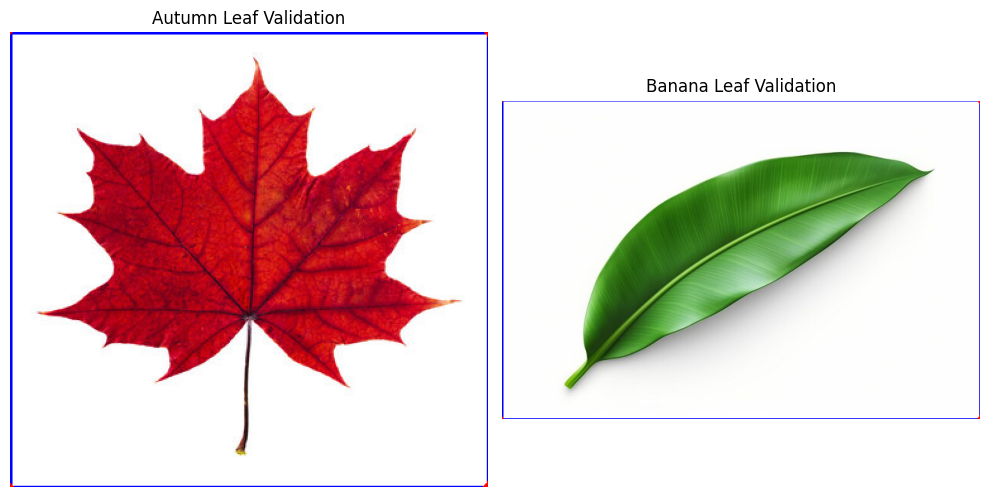

In [ ]:
def extract_features_and_validate(image):

    if len(image.shape) > 2:
        gray = image[:, :, 0]
    else:
        gray = image

    _, thresh = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)

    # Find the largest contour
    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return {'aspect_ratio': 0, 'extent': 0, 'solidity': 0, 'equivalent_diameter': 0}, None

    cnt = max(contours, key=cv2.contourArea)

    # --- Feature Calculation ---
    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = float(w) / h if h != 0 else 0

    area = cv2.contourArea(cnt)
    bounding_box_area = w * h
    extent = float(area) / bounding_box_area if bounding_box_area != 0 else 0

    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)
    solidity = float(area) / hull_area if hull_area != 0 else 0

    equivalent_diameter = np.sqrt(4 * area / np.pi)

    features = {
        'aspect_ratio': aspect_ratio,
        'extent': extent,
        'solidity': solidity,
        'equivalent_diameter': equivalent_diameter
    }

    return features, cnt



autumn_sample = next(
    item for item in leaf_images_data if item['class_name'] == 'autumn')
banana_sample = next(
    item for item in leaf_images_data if item['class_name'] == 'banana')

# Extract features and contour for validation
_, autumn_cnt = extract_features_and_validate(autumn_sample['image'])
_, banana_cnt = extract_features_and_validate(banana_sample['image'])

autumn_val_img = autumn_sample['image'].copy()
banana_val_img = banana_sample['image'].copy()

# Draw bounding rectangle (blue) and min enclosing circle (red)
x, y, w, h = cv2.boundingRect(autumn_cnt)
cv2.rectangle(autumn_val_img, (x, y), (x + w, y + h), (255, 0, 0), 2)
(cx, cy), radius = cv2.minEnclosingCircle(autumn_cnt)
cv2.circle(autumn_val_img, (int(cx), int(cy)), int(radius), (0, 0, 255), 2)

x, y, w, h = cv2.boundingRect(banana_cnt)
cv2.rectangle(banana_val_img, (x, y), (x + w, y + h), (255, 0, 0), 2)
(cx, cy), radius = cv2.minEnclosingCircle(banana_cnt)
cv2.circle(banana_val_img, (int(cx), int(cy)), int(radius), (0, 0, 255), 2)


# Display validation images
show_images([autumn_val_img, banana_val_img],
            ["Autumn Leaf Validation", "Banana Leaf Validation"],
            figsize_per_image=(5, 5))

Extract Feature Vector for each Image

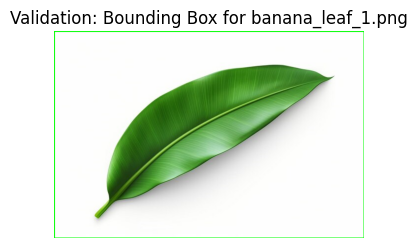

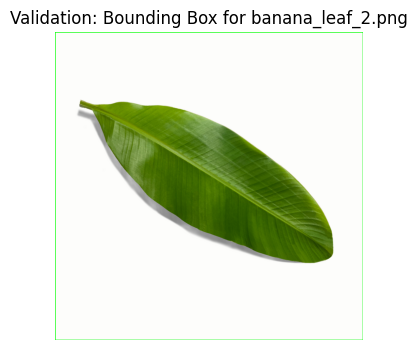

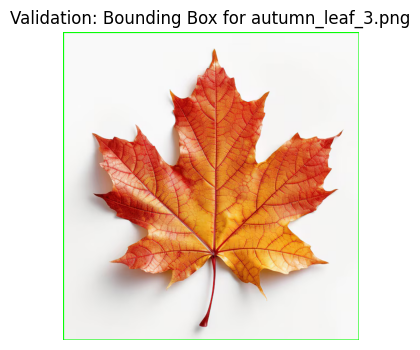

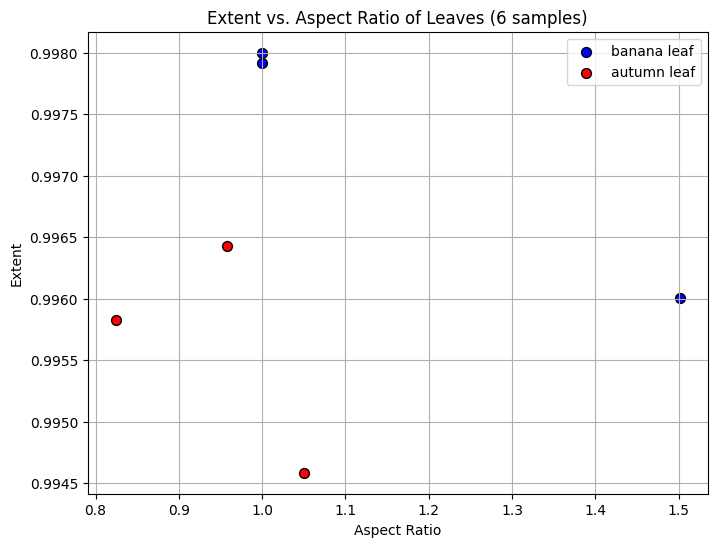

In [ ]:
feature_vectors = []
labels_for_q3 = [] 

for item_idx, item in enumerate(leaf_images_data):
    image_color = item['image']
    image_gray = cv2.cvtColor(image_color, cv2.COLOR_BGR2GRAY)
    
    _, binary_image = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    if np.sum(binary_image == 0) > np.sum(binary_image == 255): 
        contours_check, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours_check:
            largest_contour_check = max(contours_check, key=cv2.contourArea)
            mask_check = np.zeros_like(binary_image)
            cv2.drawContours(mask_check, [largest_contour_check], -1, 255, -1)
            if np.mean(binary_image[mask_check == 255]) < 128: 
                 binary_image = cv2.bitwise_not(binary_image)
    
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        print(f"No contours found for {item['filename']}. Skipping.")
        continue
    
    main_contour = max(contours, key=cv2.contourArea)
    
    validation_image = image_color.copy()
    x_br, y_br, w_br, h_br = cv2.boundingRect(main_contour)
    cv2.rectangle(validation_image, (x_br,y_br), (x_br+w_br,y_br+h_br), (0,255,0), 2) # Green rectangle
    if item_idx < 2 or item_idx == len(leaf_images_data) -1: 
        show_image(validation_image, title=f"Validation: Bounding Box for {item['filename']}", figsize=(4,4))

    # --- Extract Features ---
    current_features = []
    moments = cv2.moments(main_contour)
    contour_area = moments['m00'] 

    # 1. Aspect Ratio of Bounding Box
    aspect_ratio = float(w_br)/h_br if h_br > 0 else 0
    current_features.append(aspect_ratio)
    
    # 2. Extent (Contour Area / Bounding Box Area)
    bounding_box_area = w_br * h_br
    extent = float(contour_area)/bounding_box_area if bounding_box_area > 0 else 0
    current_features.append(extent)
    
    # 3. Solidity (Contour Area / Convex Hull Area)
    hull = cv2.convexHull(main_contour)
    hull_area = cv2.contourArea(hull)
    solidity = float(contour_area)/hull_area if hull_area > 0 else 0
    current_features.append(solidity)
    
    # 4. Hu Moments (using the first Hu moment)
    hu_moments = cv2.HuMoments(moments)
    hu_moment_1 = -np.sign(hu_moments[0,0]) * np.log10(abs(hu_moments[0,0])) if hu_moments[0,0] !=0 else 0 
    current_features.append(hu_moment_1)

    feature_vectors.append(current_features)
    labels_for_q3.append(item['label'])

X_features = np.array(feature_vectors)
y_labels_q3 = np.array(labels_for_q3)

if X_features.shape[0] > 0 and X_features.shape[1] >=2:
    feature1_idx = 0 # Aspect Ratio
    feature2_idx = 1 # Extent
    feature_names = ["Aspect Ratio", "Extent", "Solidity", "Log(Hu Moment 1)"]

    plt.figure(figsize=(8,6))
    plot_colors = ['blue', 'red'] 
    class_names_plot = ['banana leaf', 'autumn leaf']

    for label_val in np.unique(y_labels_q3):
        subset_indices = np.where(y_labels_q3 == label_val)
        plt.scatter(X_features[subset_indices, feature1_idx], 
                    X_features[subset_indices, feature2_idx], 
                    c=plot_colors[label_val], 
                    label=class_names_plot[label_val],
                    edgecolors='k', s=50) 

    plt.xlabel(feature_names[feature1_idx])
    plt.ylabel(feature_names[feature2_idx])
    plt.title(f'{feature_names[feature2_idx]} vs. {feature_names[feature1_idx]} of Leaves ({X_features.shape[0]} samples)')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Not enough features or data to plot.")

Classify by a Simple Model

In [ ]:

X = X_features 
y = y_labels_q3  # 0 for banana leaf, 1 for autumn leaf

if X.shape[0] > 0:
    print("Feature matrix X shape:", X.shape)
    print("Label vector y:", y)
    print("Classes in y:", np.unique(y, return_counts=True))
else:
    print("X or y is empty. Cannot proceed with classification.")

Feature matrix X shape: (6, 4)
Label vector y: [0 0 0 1 1 1]
Classes in y: (array([0, 1]), array([3, 3], dtype=int64))


Accuracy of the linear classifier on the training data: 0.50
Not perfect separability; consider more data or different features.


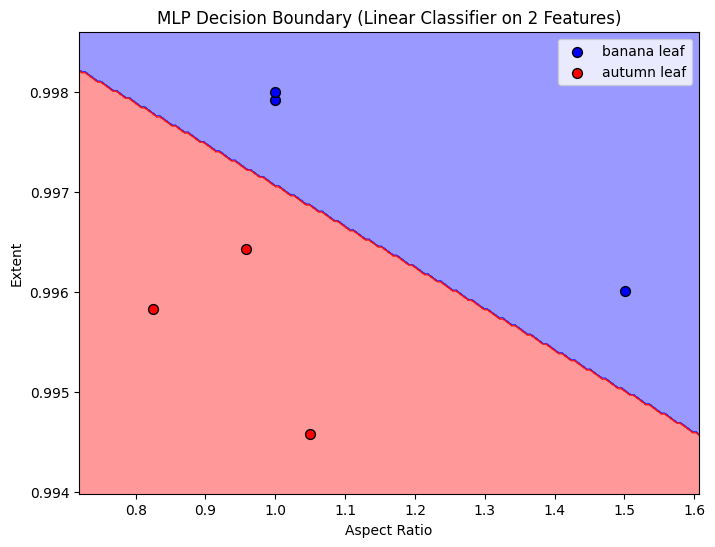

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


if X.shape[0] > 0 and len(np.unique(y)) > 1:
    mlp = MLPClassifier(
        hidden_layer_sizes=(),       
        max_iter=10000,
        random_state=14,
        solver='lbfgs',             
        activation='identity'       
    )
    mlp.fit(X, y)
    y_pred = mlp.predict(X)
    accuracy = accuracy_score(y, y_pred)
    print(
        f"Accuracy of the linear classifier on the training data: {accuracy:.2f}")
    if accuracy == 1.0:
        print("The features are linearly separable with this linear model.")
    else:
        print("Not perfect separability; consider more data or different features.")

    if X.shape[1] >= 2:
        feature1_idx = 0
        feature2_idx = 1
        feature_names_plot = ["Aspect Ratio", "Extent"]
        plot_colors_q3 = ['blue', 'red']
        class_names_q3_plot = ['banana leaf', 'autumn leaf']

        # Extract the two features
        X_plot = X[:, [feature1_idx, feature2_idx]] 

        scaler = StandardScaler()
        X_plot_scaled = scaler.fit_transform(X_plot)

        mlp_2d = MLPClassifier(
            hidden_layer_sizes=(),
            max_iter=10000,
            random_state=14,
            solver='lbfgs',
            activation='identity'
        )
        mlp_2d.fit(X_plot_scaled, y)

        x_min, x_max = X_plot_scaled[:, 0].min(
        ) - 0.5, X_plot_scaled[:, 0].max() + 0.5
        y_min, y_max = X_plot_scaled[:, 1].min(
        ) - 0.5, X_plot_scaled[:, 1].max() + 0.5

        if x_min >= x_max:
            x_max = x_min + 0.1
        if y_min >= y_max:
            y_max = y_min + 0.1

        xx_scaled, yy_scaled = np.meshgrid(
            np.linspace(x_min, x_max, 200),
            np.linspace(y_min, y_max, 200)
        )

        grid_points_scaled = np.c_[xx_scaled.ravel(), yy_scaled.ravel()]
        Z = mlp_2d.predict(grid_points_scaled)
        Z = Z.reshape(xx_scaled.shape)


        grid_original = scaler.inverse_transform(grid_points_scaled)
        X_mesh_orig = grid_original[:, 0].reshape(
            xx_scaled.shape)  # Aspect Ratio axis
        Y_mesh_orig = grid_original[:, 1].reshape(
            xx_scaled.shape)  # Extent axis

        plt.figure(figsize=(8, 6))

        plt.contourf(
            X_mesh_orig,
            Y_mesh_orig,
            Z,
            alpha=0.4,
            cmap=ListedColormap(plot_colors_q3)
        )

        for label_val in np.unique(y):
            idxs = np.where(y == label_val)
            plt.scatter(
                X_plot[idxs, 0],        
                X_plot[idxs, 1],        
                c=plot_colors_q3[label_val],
                label=class_names_q3_plot[label_val],
                edgecolor='k',
                s=50
            )

        plt.xlabel(feature_names_plot[0])
        plt.ylabel(feature_names_plot[1])
        plt.title('MLP Decision Boundary (Linear Classifier on 2 Features)')
        plt.legend(loc='best')
        plt.show()

else:
    print("Not enough data or classes to train the classifier and plot decision boundary.")